## Step 1 - Layout segmentation with Surya
Chay layout de chia trang thanh cac block (Text/Table/Figure/...) truoc khi trich xuat text.
Cell ben duoi se:
- tim PDF trong thu muc `data`
- chon 1 file de thu nghiem
- chay layout cho `max_pages` trang dau.

In [ ]:
from pathlib import Path

DATA_DIR = Path('/media/data3/users/huytq/huy/surya/data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/media/data3/users/huytq/surya/data')

pdf_files = sorted(DATA_DIR.glob('*.pdf'))
assert pdf_files, f'Khong tim thay PDF trong {DATA_DIR}'

pdf_index = 7
pdf_path = pdf_files[pdf_index]

max_pages = 3
print(f'Tim thay {len(pdf_files)} file PDF')
for i, p in enumerate(pdf_files):
    print(f'[{i}] {p.name}')
print(f'\nDang test: {pdf_path.name}, max_pages={max_pages}')
print(f'DATA_DIR: {DATA_DIR}')

Tim thay 8 file PDF
[0] Public001.pdf
[1] Public002.pdf
[2] Public003.pdf
[3] Public004.pdf
[4] Public005.pdf
[5] Public257.pdf
[6] Public282.pdf
[7] Public283.pdf

Dang test: Public283.pdf, max_pages=3
DATA_DIR: /media/data3/users/huytq/huy/surya/data


In [ ]:
import torch
import pypdfium2 as pdfium # thư viện để đọc và render PDF
from surya.foundation import FoundationPredictor
from surya.layout import LayoutPredictor
from surya.settings import settings as surya_settings

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print('Device:', device)

layout_model = LayoutPredictor(
    FoundationPredictor(
        checkpoint=surya_settings.LAYOUT_MODEL_CHECKPOINT,
        device=device,
    )
)

pdf_doc = pdfium.PdfDocument(str(pdf_path))
page_count = len(pdf_doc)
run_pages = min(max_pages, page_count)

images = []
for page_id in range(run_pages):
    page = pdf_doc[page_id]
    # scale=96/72 ~ 96 DPI, giong lowres image trong Marker
    pil_image = page.render(scale=96 / 72).to_pil()
    images.append(pil_image)

layout_results = layout_model(images, batch_size=min(6, len(images)))

print(f'Processed {len(layout_results)} / {page_count} pages')
for i, result in enumerate(layout_results):
    labels = [b.label for b in result.bboxes]
    uniq = sorted(set(labels))
    print(f'Page {i}: {len(labels)} blocks | labels={uniq}')

Device: cpu


Recognizing Layout: 100%|██████████| 3/3 [00:33<00:00, 11.32s/it]

Processed 3 / 17 pages
Page 0: 20 blocks | labels=['ListItem', 'PageFooter', 'Picture', 'SectionHeader', 'Text']
Page 1: 16 blocks | labels=['ListItem', 'PageFooter', 'Picture', 'SectionHeader', 'Text']
Page 2: 18 blocks | labels=['ListItem', 'PageFooter', 'Picture', 'SectionHeader', 'Text']


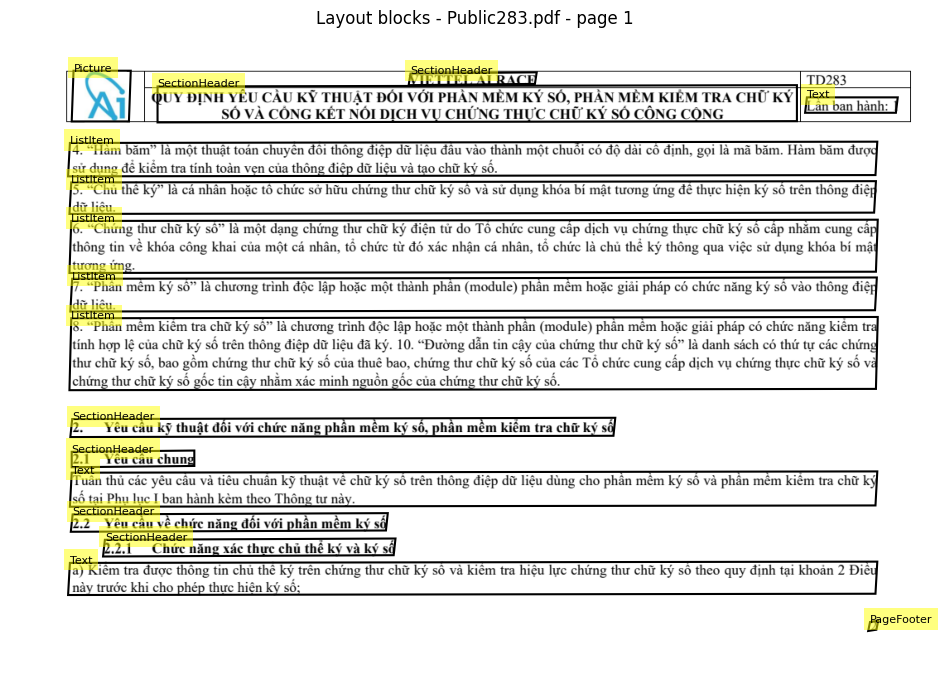

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

viz_page = 1
img = images[viz_page]
result = layout_results[viz_page]

fig, ax = plt.subplots(figsize=(12, 16))
ax.imshow(img)
ax.set_title(f'Layout blocks - {pdf_path.name} - page {viz_page}')
ax.axis('off')

for box in result.bboxes:
    poly = Polygon(box.polygon, closed=True, fill=False, linewidth=1.5)
    ax.add_patch(poly)
    x0, y0 = box.polygon[0]
    ax.text(x0, y0, box.label, fontsize=8, bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='none'))

plt.show()

## Step 2 - Kiem tra chat luong text so tu PDF
Muc tieu: danh gia text trich xuat truc tiep tu PDF co du tot de bo qua OCR hay khong.
Heuristic duoc lay theo Marker (space/newline/alphanum/ky tu loi).

In [ ]:
import re
import pandas as pd

ocr_space_threshold = 0.7
ocr_newline_threshold = 0.6
ocr_alphanum_threshold = 0.3
ocr_invalid_chars = (chr(0xFFFD), '�')

def alphanum_ratio(text: str) -> float:
    t = text.replace(' ', '').replace('\n', '')
    if len(t) == 0:
        return 1.0
    return sum(ch.isalnum() for ch in t) / len(t)

def detect_bad_ocr_like_marker(text: str):
    if len(text) == 0:
        return True, 'empty'

    spaces = len(re.findall(r'\s+', text))
    alpha_chars = len(re.sub(r'\s+', '', text))
    space_ratio = spaces / (alpha_chars + spaces + 1e-8)
    if space_ratio > ocr_space_threshold:
        return True, f'space_ratio={space_ratio:.3f}'

    newlines = len(re.findall(r'\n+', text))
    non_newlines = len(re.sub(r'\n+', '', text))
    newline_ratio = newlines / (newlines + non_newlines + 1e-8)
    if newline_ratio > ocr_newline_threshold:
        return True, f'newline_ratio={newline_ratio:.3f}'

    alpha_num = alphanum_ratio(text)
    if alpha_num < ocr_alphanum_threshold:
        return True, f'alphanum_ratio={alpha_num:.3f}'

    invalid_chars = sum(c in ocr_invalid_chars for c in text)
    if invalid_chars > max(6.0, len(text) * 0.03):
        return True, f'invalid_chars={invalid_chars}'

    return False, 'ok'

def extract_page_texts_pdftext(pdf_path: str):
    from pdftext.extraction import dictionary_output

    pages = dictionary_output(
        pdf_path,
        keep_chars=False,
        workers=1,
        flatten_pdf=True,
        quote_loosebox=False,
        disable_links=True,
    )

    page_texts = {}
    for page in pages:
        pid = page['page']
        lines = []
        for block in page.get('blocks', []):
            for line in block.get('lines', []):
                line_text = ''.join(span.get('text', '') for span in line.get('spans', []))
                if line_text.strip():
                    lines.append(line_text)
        page_texts[pid] = '\n'.join(lines)
    return page_texts

extract_backend = 'pdftext'
try:
    page_texts = extract_page_texts_pdftext(str(pdf_path))
except Exception as e:
    extract_backend = f'pdfium_fallback ({type(e).__name__})'
    page_texts = {}
    with pdfium.PdfDocument(str(pdf_path)) as doc:
        for pid in range(len(doc)):
            text = ''
            try:
                textpage = doc[pid].get_textpage()
                try:
                    text = textpage.get_text_range()
                except Exception:
                    text = textpage.get_text_bounded()
            except Exception:
                text = ''
            page_texts[pid] = text

rows = []
for pid in sorted(page_texts.keys()):
    text = page_texts[pid]
    is_bad, reason = detect_bad_ocr_like_marker(text)
    rows.append({
        'page': pid,
        'chars': len(text),
        'alphanum_ratio': round(alphanum_ratio(text), 4),
        'is_bad_text': is_bad,
        'reason': reason,
        'preview': text[:120].replace('\n', ' '),
    })

quality_df = pd.DataFrame(rows)

bad_pages = quality_df[quality_df['is_bad_text']]
good_pages = quality_df[~quality_df['is_bad_text']]

print(f'Backend: {extract_backend}')
print(f'Tong so trang: {len(quality_df)}')
print(f'Trang text TOT (co the bo qua OCR): {len(good_pages)}')
print(f'Trang text XAU (nen OCR): {len(bad_pages)}')

if len(quality_df) > 0:
    good_ratio = len(good_pages) / len(quality_df)
    print(f'Ty le trang tot: {good_ratio:.1%}')

print('\nTop trang nghi ngo (neu co):')
display(bad_pages[['page', 'chars', 'alphanum_ratio', 'reason', 'preview']].head(10))

print('\nMau 10 trang dau:')
display(quality_df[['page', 'chars', 'alphanum_ratio', 'is_bad_text', 'reason']].head(10))

Backend: pdftext
Tong so trang: 17
Trang text TOT (co the bo qua OCR): 17
Trang text XAU (nen OCR): 0
Ty le trang tot: 100.0%

Top trang nghi ngo (neu co):


,page,chars,alphanum_ratio,reason,preview



Mau 10 trang dau:


,page,chars,alphanum_ratio,is_bad_text,reason
0,0,1786,0.9614,False,ok
1,1,2005,0.9714,False,ok
2,2,2350,0.9814,False,ok
3,3,2267,0.9789,False,ok
4,4,2230,0.9714,False,ok
5,5,1781,0.9792,False,ok
6,6,2131,0.9698,False,ok
7,7,1744,0.9502,False,ok
8,8,1435,0.9365,False,ok
9,9,1738,0.9508,False,ok


## Step 3 - Gan text so vao tung block layout
Y tuong:
- Lay line text + bbox tu pdftext
- Lay bbox block tu ket qua layout
- Gan moi line vao block co intersection area lon nhat
- Tong hop text theo block de kiem tra nhanh chat luong segmentation + assignment

Tong line da gan: 72
Tong block co text: 33

Preview block text (trang 0):


,page,block_idx,block_label,line_count,avg_overlap
0,0,0,Picture,1,0.141697
1,0,1,SectionHeader,1,0.090599
2,0,2,SectionHeader,2,0.578169
3,0,4,SectionHeader,2,0.404242
4,0,5,SectionHeader,2,0.221080
5,0,6,Text,1,0.389531
6,0,7,ListItem,2,0.803701
7,0,8,ListItem,3,0.782857
8,0,9,SectionHeader,2,0.192145
9,0,10,Text,1,0.213725



--- Page 0 | Block 0 | Picture ---
1. Quy định chung

--- Page 0 | Block 1 | SectionHeader ---
VIETTEL AI RACE TD283

--- Page 0 | Block 2 | SectionHeader ---
QUY ĐỊNH YÊU CẦU KỸ THUẬT ĐỐI VỚI PHẦN MỀM KÝ SỐ, PHẦN MỀM KIỂM TRA CHỮ KÝ
SỐ VÀ CỔNG KẾT NỐI DỊCH VỤ CHỨNG THỰC CHỮ KÝ SỐ CÔNG CỘNG Lần ban hành: 1

--- Page 0 | Block 4 | SectionHeader ---
1.1 Phạm vi điều chỉnh
Thông tư này quy định các nội dung sau:

--- Page 0 | Block 5 | SectionHeader ---
1. Yêu cầu kỹ thuật đối với phần mềm ký số, phần mềm kiểm tra chữ ký số theo quy định tại Điều 17, Nghị định số 23/2025/NĐ-CP ngày
21 tháng 02 năm 2025 của Chính phủ quy định về chữ ký điện tử và dịch vụ tin cậy.


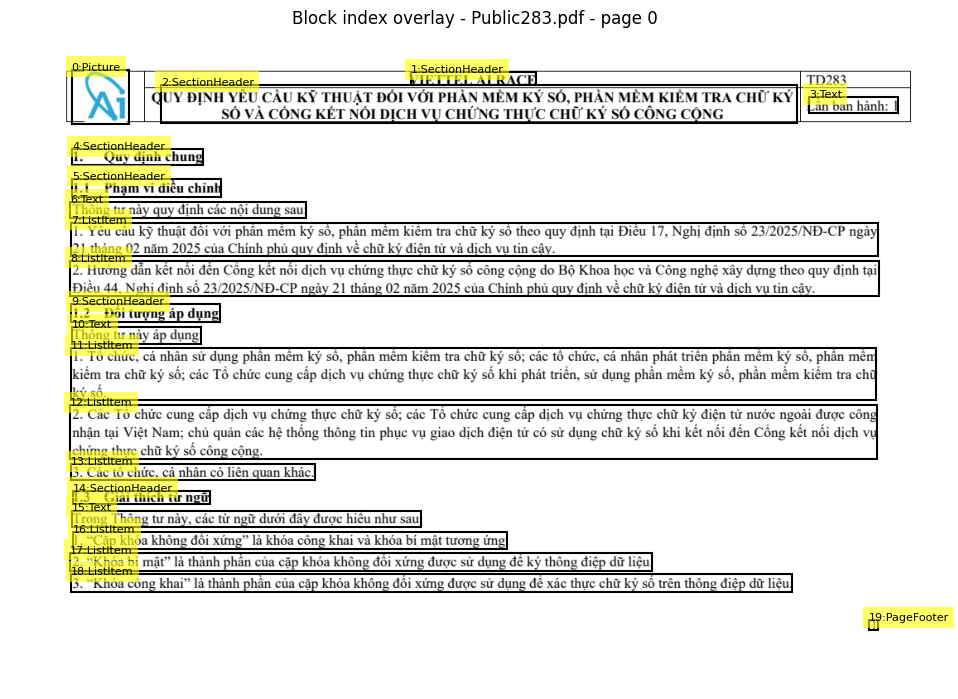

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from pdftext.extraction import dictionary_output

# Chon so trang de gan text (nen khop so trang da chay layout)
assign_pages = run_pages

# Lay line-level text + bbox tu pdftext
def extract_line_level_pdftext(pdf_path: str, page_count: int):
    pages = dictionary_output(
        pdf_path,
        page_range=list(range(page_count)),
        keep_chars=False,
        workers=1,
        flatten_pdf=True,
        quote_loosebox=False,
        disable_links=True,
    )

    by_page = {i: [] for i in range(page_count)}
    for page in pages:
        pid = page['page']
        for block in page.get('blocks', []):
            for line in block.get('lines', []):
                text = ''.join(span.get('text', '') for span in line.get('spans', []))
                if not text.strip():
                    continue
                bbox = line['bbox']  # [x0, y0, x1, y1] in page coord
                by_page[pid].append({
                    'text': text.strip(),
                    'bbox': bbox,
                    'x0': bbox[0],
                    'y0': bbox[1],
                    'x1': bbox[2],
                    'y1': bbox[3],
                    'xc': (bbox[0] + bbox[2]) / 2.0,
                    'yc': (bbox[1] + bbox[3]) / 2.0,
                })
    return by_page

def bbox_area(b):
    return max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])

def intersection_area(a, b):
    x0 = max(a[0], b[0])
    y0 = max(a[1], b[1])
    x1 = min(a[2], b[2])
    y1 = min(a[3], b[3])
    return max(0.0, x1 - x0) * max(0.0, y1 - y0)

def polygon_to_bbox(poly):
    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]
    return [min(xs), min(ys), max(xs), max(ys)]

def join_lines_reading_order(group_df: pd.DataFrame) -> str:
    # Reading order trong block: top-to-bottom, left-to-right
    ordered = group_df.sort_values(['yc', 'x0'], ascending=[True, True], kind='mergesort')
    return '\n'.join(ordered['line_text'].tolist())

line_data = extract_line_level_pdftext(str(pdf_path), assign_pages)

assign_rows = []
for pid in range(assign_pages):
    blocks = layout_results[pid].bboxes
    block_bboxes = [polygon_to_bbox(b.polygon) for b in blocks]

    for line in line_data.get(pid, []):
        line_bbox = line['bbox']
        best_idx = None
        best_inter = 0.0

        for bi, bb in enumerate(block_bboxes):
            inter = intersection_area(line_bbox, bb)
            if inter > best_inter:
                best_inter = inter
                best_idx = bi

        line_area = max(bbox_area(line_bbox), 1e-8)
        overlap_ratio = best_inter / line_area

        # Gan khi co overlap du lon
        if best_idx is not None and overlap_ratio > 0.00:
            assign_rows.append({
                'page': pid,
                'block_idx': best_idx,
                'block_label': blocks[best_idx].label,
                'line_text': line['text'],
                'x0': line['x0'],
                'y0': line['y0'],
                'x1': line['x1'],
                'y1': line['y1'],
                'xc': line['xc'],
                'yc': line['yc'],
                'overlap_ratio': overlap_ratio,
            })

assign_df = pd.DataFrame(assign_rows)

if assign_df.empty:
    print('Khong gan duoc line nao vao layout block.')
else:
    # Tong hop theo block + reading order noi block
    block_text_df = (
        assign_df
        .groupby(['page', 'block_idx', 'block_label'], as_index=False)
        .apply(
            lambda g: pd.Series({
                'line_count': len(g),
                'avg_overlap': g['overlap_ratio'].mean(),
                'text': join_lines_reading_order(g),
            })
        )
        .reset_index(drop=True)
        .sort_values(['page', 'block_idx'])
    )

    print(f'Tong line da gan: {len(assign_df)}')
    print(f'Tong block co text: {len(block_text_df)}')

    print('\nPreview block text (trang 0):')
    display(
        block_text_df[block_text_df['page'] == 0][['page', 'block_idx', 'block_label', 'line_count', 'avg_overlap']]
        .sort_values(['block_idx'])
    )

    # Hien 1 vai block dau tien de doc nhanh
    sample = block_text_df[block_text_df['page'] == 0].sort_values('block_idx').head(5)
    for _, row in sample.iterrows():
        print(f"\n--- Page {row['page']} | Block {row['block_idx']} | {row['block_label']} ---")
        print(row['text'][:10000])

    # Overlay block index tren anh de doi chieu voi text da gan
    page_to_viz = 0
    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(images[page_to_viz])
    ax.set_title(f'Block index overlay - {pdf_path.name} - page {page_to_viz}')
    ax.axis('off')

    for bi, block in enumerate(layout_results[page_to_viz].bboxes):
        bb = polygon_to_bbox(block.polygon)
        w = bb[2] - bb[0]
        h = bb[3] - bb[1]
        rect = Rectangle((bb[0], bb[1]), w, h, fill=False, linewidth=1.5)
        ax.add_patch(rect)
        ax.text(bb[0], bb[1], f'{bi}:{block.label}', fontsize=8, bbox=dict(facecolor='yellow', alpha=0.6, edgecolor='none'))

    plt.show()

In [12]:
# Debug: xem block nao khong duoc gan text
page_to_check = 0

layout_labels = []
for i, b in enumerate(layout_results[page_to_check].bboxes):
    bb = polygon_to_bbox(b.polygon)
    layout_labels.append({
        'block_idx': i,
        'label': b.label,
        'bbox': bb,
    })
layout_df = pd.DataFrame(layout_labels)

assigned_counts = (
    assign_df[assign_df['page'] == page_to_check]
    .groupby('block_idx', as_index=False)
    .agg(assigned_lines=('line_text', 'count'), avg_overlap=('overlap_ratio', 'mean'))
)

inspect_df = layout_df.merge(assigned_counts, on='block_idx', how='left')
inspect_df['assigned_lines'] = inspect_df['assigned_lines'].fillna(0).astype(int)
inspect_df['avg_overlap'] = inspect_df['avg_overlap'].fillna(0.0)

print('Tat ca block trang 0 va so line duoc gan:')
display(inspect_df[['block_idx', 'label', 'assigned_lines', 'avg_overlap']])

print('\nCac block KHONG co text gan vao:')
display(inspect_df[inspect_df['assigned_lines'] == 0][['block_idx', 'label', 'bbox']])

Tat ca block trang 0 va so line duoc gan:


,block_idx,label,assigned_lines,avg_overlap
0,0,Picture,1,0.141697
1,1,SectionHeader,1,0.090599
2,2,SectionHeader,2,0.578169
3,3,Text,0,0.000000
4,4,SectionHeader,2,0.404242
5,5,SectionHeader,2,0.221080
6,6,Text,1,0.389531
7,7,ListItem,2,0.803701
8,8,ListItem,3,0.782857
9,9,SectionHeader,2,0.192145



Cac block KHONG co text gan vao:


,block_idx,label,bbox
3,3,Text,"[963.9814453125, 78.7021484375, 1071.456054687..."
13,13,ListItem,"[73.4775390625, 522.2255859375, 367.3876953125..."
14,14,SectionHeader,"[75.12255859375, 554.0166015625, 240.721191406..."
15,15,Text,"[74.02587890625, 578.0537109375, 496.247558593..."
16,16,ListItem,"[75.6708984375, 603.6416015625, 599.8837890625..."
17,17,ListItem,"[71.83251953125, 628.841796875, 774.8041992187..."
18,18,ListItem,"[73.4775390625, 655.205078125, 944.2412109375,..."
19,19,PageFooter,"[1036.3623046875, 710.2578125, 1047.3291015625..."
